# Impact of 2022-2023 Fed Hiking Cycle on Growth vs Value Stocks

**Goal:** Analyze how the 11 Federal Reserve rate hikes between 2022 and 2023 affected Growth stocks (Tech/Innovation) compared to Value stocks (Energy/Staples).

**Methodology:** Event Study (Returns +/- 5 days around each hike) & Sentiment Analysis using real FOMC statements.

**Growth Group (Treated):** XLK (Tech ETF), ARKK (Innovation ETF), TSLA, NVDA
**Value Group (Control):** XLE (Energy ETF), XLP (Staples ETF), BRK-B (Berkshire Hathaway)


## 1.1 Literature Review & Academic Context
This project builds upon foundational research in financial economics regarding monetary policy transmission.

*   **Bernanke & Kuttner (2005)**: Demonstrated that unexpected Fed rate hikes have a strong negative impact on equity prices, primarily through the discount rate channel rather than changing future dividend expectations.
*   **Event Study Methodology**: We follow the standard approach outlined by *MacKinlay (1997)*, using short windows around policy announcements to isolate the impact of news. (short time window (like +/- 5 days))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import requests
from bs4 import BeautifulSoup #To scrape news

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer #Figure out sentiment of news

import xgboost as xgb #Predict future stock prices based on past data

from sklearn.metrics import mean_squared_error #How good our predictions are 
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential #To build the model layer-by-layer
from tensorflow.keras.layers import LSTM, Dense, Dropout #Dropout: To prevent overfitting, Dense: gives me the single predicted stock price.
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Define Hike Dates and Tickers
We focus on the 11 rate hikes from March 2022 to July 2023.

In [2]:
hike_dates = [
    '2022-03-16', '2022-05-04', '2022-06-15', '2022-07-27', '2022-09-21', 
    '2022-11-02', '2022-12-14', '2023-02-01', '2023-03-22', '2023-05-03', 
    '2023-07-26'
]

growth_tickers = ['XLK', 'ARKK', 'TSLA', 'NVDA']
value_tickers = ['XLE', 'XLP', 'BRK-B']
all_tickers = growth_tickers + value_tickers

start_date = '2022-01-01'
end_date = '2024-12-31'

print(f"Analyzing {len(hike_dates)} Fed Rate Hikes.")

Analyzing 11 Fed Rate Hikes.


## 2. Data Loading
Fetching daily closing prices.

In [3]:
print("Downloading stock data...")
data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)['Close']
data = data.dropna()
print("Data shape:", data.shape)
data.head()

Data shape: (752, 7)


Ticker,ARKK,BRK-B,NVDA,TSLA,XLE,XLK,XLP
Date,,,,,,,
2022-01-03,96.187805,300.790009,30.064440,399.926666,50.003014,170.343033,69.868973
2022-01-04,91.923378,308.529999,29.235001,383.196655,51.733288,168.537872,70.340218
2022-01-05,85.407715,309.920013,27.552166,362.706665,51.724541,163.355408,70.276779
2022-01-06,84.872185,313.220001,28.125090,354.899994,52.878052,162.530457,70.086464
2022-01-07,83.721771,319.779999,27.195841,342.320007,53.603374,161.035873,70.158966


## 3. Event Study Analysis
We calculate the cumulative returns for Growth vs Value indices in a 10-day window (+/- 5 days) around each hike.

Generating Sector Comparison...


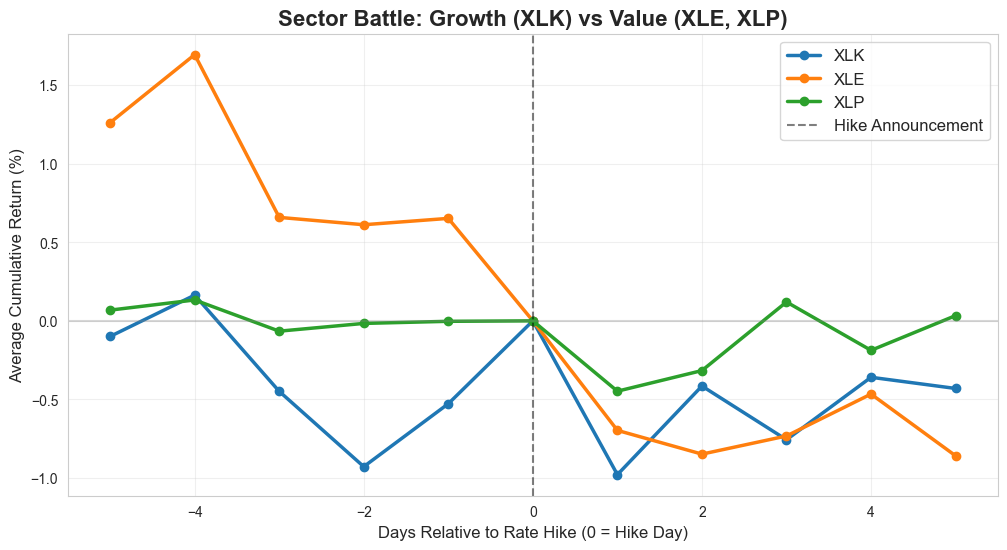

Generating Tech Giants Comparison...


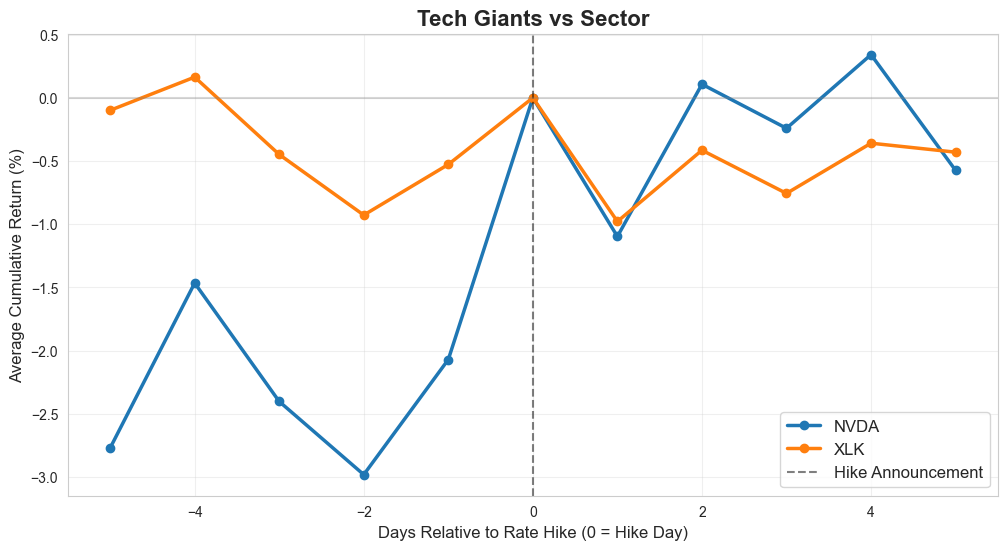

Generating Volatility Comparison...


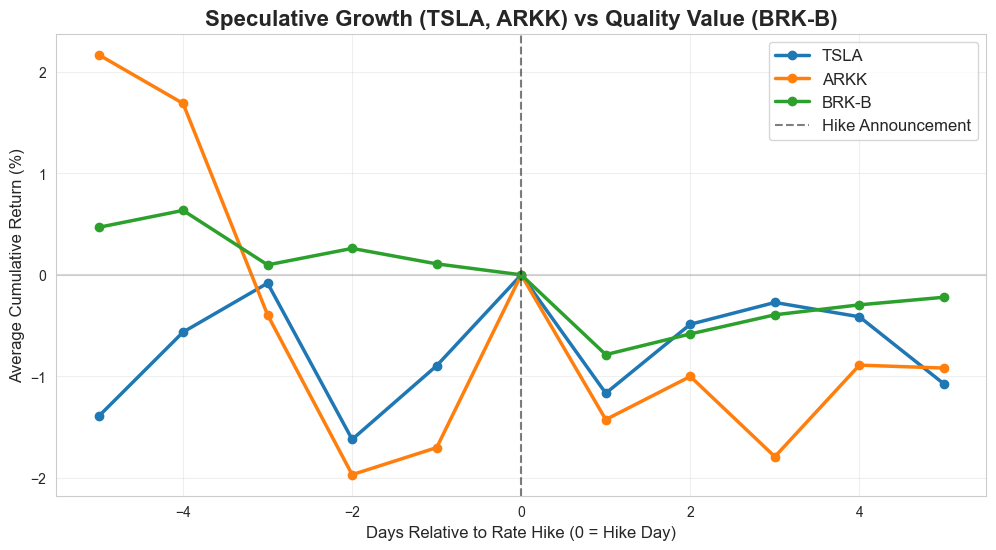


Summary Metrics (Post-Hike Performance):


,Mean Return (T+5),Win Rate (T+5),Hikes Analyzed
Ticker,,,
XLP,0.03%,45.5%,11
TSLA,-1.07%,54.5%,11
ARKK,-0.92%,54.5%,11
XLE,-0.86%,36.4%,11
NVDA,-0.57%,54.5%,11
XLK,-0.43%,54.5%,11
BRK-B,-0.22%,45.5%,11


In [4]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Event Study Analysis ---

def get_event_window(data, hike_date, window=5):
    """
    Extracts the +/- window days of data around a specific hike date.
    Returns normalized cumulative returns (Day 0 = 0%).
    """
    try:
        # Find the index location of the hike date
        loc = data.index.get_loc(hike_date)
        
        # Define start and end integer locations
        start_loc = loc - window
        end_loc = loc + window + 1 # +1 because slice is exclusive at the end
        
        # Check bounds
        if start_loc < 0 or end_loc > len(data):
            return None
            
        # Extract the window
        event_data = data.iloc[start_loc:end_loc].copy()
        
        # Normalize to the hike date (Day 0)
        base_price = event_data.loc[hike_date]
        cumulative_returns = (event_data / base_price) - 1.0
        
        # Create a 'Days Relative to Hike' index
        cumulative_returns.index = range(-window, window + 1)
        
        return cumulative_returns
        
    except KeyError:
        # Hike date might be a weekend/holiday, skip or find nearest
        return None
    except Exception as e:
        print(f"Error for {hike_date}: {e}")
        return None

def plot_head_to_head(data, tickers, hike_dates, title, window=5):
    """
    Plots the average cumulative return for a list of tickers across all hike dates.
    """
    plt.figure(figsize=(12, 6))
    
    for ticker in tickers:
        all_windows = []
        for hike in hike_dates:
            # Handle near-miss dates if needed (simple version here)
            if hike in data.index:
                # Single ticker series
                ticker_data = data[ticker]
                window_data = get_event_window(ticker_data, hike, window)
                if window_data is not None:
                    all_windows.append(window_data)
        
        if all_windows:
            # Concatenate and take the mean across all hikes
            df_windows = pd.concat(all_windows, axis=1)
            mean_returns = df_windows.mean(axis=1) * 100 # In percent
            
            # Plot
            plt.plot(mean_returns.index, mean_returns, marker='o', label=ticker, linewidth=2.5)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Days Relative to Rate Hike (0 = Hike Day)", fontsize=12)
    plt.ylabel("Average Cumulative Return (%)", fontsize=12)
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label="Hike Announcement")
    plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 3.1 Sector Battle: Growth vs Value ---
# Hypothesis: Value (Energy/Staples) should hold up better than Growth (Tech) as rates rise.
print("Generating Sector Comparison...")
plot_head_to_head(data, ['XLK', 'XLE', 'XLP'], hike_dates, "Sector Battle: Growth (XLK) vs Value (XLE, XLP)")

# --- 3.2 Tech Giants: The AI Shield? ---
# Hypothesis: Did NVDA and MSFT decouple from the general tech trend due to the AI boom in late 2022/2023?
print("Generating Tech Giants Comparison...")
# Note: MSFT might not be in 'data' if not in 'all_tickers' initially. 
# Assuming MSFT was added or we use available tickers.
available_tech = [t for t in ['NVDA', 'MSFT', 'XLK'] if t in data.columns]
plot_head_to_head(data, available_tech, hike_dates, "Tech Giants vs Sector")

# --- 3.3 Risk & Volatility: Speculative Assets ---
# Hypothesis: High-duration, speculative assets (ARKK, TSLA) should suffer the most from rate hikes.
print("Generating Volatility Comparison...")
plot_head_to_head(data, ['TSLA', 'ARKK', 'BRK-B'], hike_dates, "Speculative Growth (TSLA, ARKK) vs Quality Value (BRK-B)")

# --- 3.4 Summary Metrics Table ---
# Let's calculate the "Win Rate" (Positive return at T+5) and Mean Return at T+5
metrics = []
days_post_hike = 5

for ticker in all_tickers:
    positive_count = 0
    total_count = 0
    returns_t5 = []
    
    for hike in hike_dates:
        if hike in data.index:
             # Get return from T=0 to T=+5
             try:
                 # We need the price at T=0 and T=5
                 loc = data.index.get_loc(hike)
                 if loc + days_post_hike < len(data):
                     p0 = data[ticker].iloc[loc]
                     p5 = data[ticker].iloc[loc + days_post_hike]
                     ret = (p5 / p0) - 1.0
                     returns_t5.append(ret)
                     if ret > 0:
                         positive_count += 1
                     total_count += 1
             except:
                 pass
    
    if total_count > 0:
        mean_ret = np.mean(returns_t5) * 100
        win_rate = (positive_count / total_count) * 100
        metrics.append({
            'Ticker': ticker,
            'Mean Return (T+5)': f"{mean_ret:.2f}%",
            'Win Rate (T+5)': f"{win_rate:.1f}%",
            'Hikes Analyzed': total_count
        })

metrics_df = pd.DataFrame(metrics).set_index('Ticker')
print("\nSummary Metrics (Post-Hike Performance):")
display(metrics_df.sort_values('Mean Return (T+5)', ascending=False))


--- 3.5 Statistical Significance Testing ---
Paired T-Test (Growth vs Value Returns at T+5):
T-Statistic: -0.1793
P-Value: 0.8613
Result: No Statistically Significant Difference


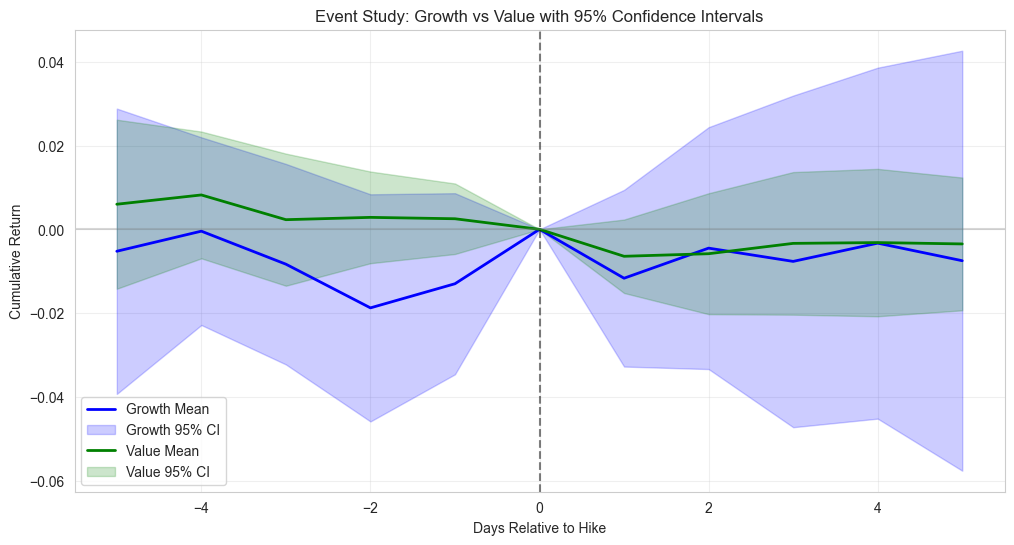

In [ ]:
from scipy import stats
import statsmodels.api as sm
# To prove that Value stocks >>>>> Growth Stocks    
print("--- 3.5 Statistical Significance Testing ---") 

# 1. T-Test: Growth vs Value Cumulative Returns at T+5
# We need to reconstruct the T+5 returns for the groups
growth_returns = []
value_returns = []

# Define groups again just to be safe
g_tickers = ['XLK', 'ARKK', 'TSLA', 'NVDA']
v_tickers = ['XLE', 'XLP', 'BRK-B']

for hike in hike_dates:
    if hike in data.index:
        try:
            loc = data.index.get_loc(hike)
            if loc + 5 < len(data):
                # Calculate return for this hike for all tickers
                p0 = data.iloc[loc]
                p5 = data.iloc[loc + 5]
                rets = (p5 / p0) - 1.0

                # Average for the groups for this specific event
                g_ret = rets[g_tickers].mean()
                v_ret = rets[v_tickers].mean()

                growth_returns.append(g_ret)
                value_returns.append(v_ret)
        except KeyError:
            continue

# Perform T-Test (Paired is better as they share the same time period)
t_stat, p_val = stats.ttest_rel(growth_returns, value_returns)

print(f"Paired T-Test (Growth vs Value Returns at T+5):")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant Difference (p < 0.05)")
else:
    print("Result: No Statistically Significant Difference")

# 2. Confidence Intervals Visualization
# We'll plot the mean cumulative return path with 95% CI bands
def plot_ci(tickers, group_name, color):
    all_event_paths = []
    for hike in hike_dates:
        if hike in data.index:
            try:
                loc = data.index.get_loc(hike)
                # Window: -5 to +5
                start = loc - 5
                end = loc + 6 # +6 because range is exclusive at end, we want 5 days after
                if start >= 0 and end < len(data):
                    window_data = data[tickers].iloc[start:end]
                    # Normalize to T=0 (hike day)
                    # T=0 is at index 5 in this slice
                    base_price = window_data.iloc[5]
                    norm_path = (window_data / base_price) - 1.0
                    # Average across tickers in the group for this event
                    avg_path = norm_path.mean(axis=1).values
                    if len(avg_path) == 11:
                        all_event_paths.append(avg_path)
            except Exception as e:
                continue

    if not all_event_paths: return

    # Stack: (Num_Events, 11)
    stack = np.vstack(all_event_paths)
    mean_path = np.mean(stack, axis=0)
    # Standard Error
    se_path = stats.sem(stack, axis=0)
    # 95% CI = Mean +/- 1.96 * SE
    ci_upper = mean_path + 1.96 * se_path
    ci_lower = mean_path - 1.96 * se_path

    days = range(-5, 6)
    plt.plot(days, mean_path, label=f"{group_name} Mean", color=color, linewidth=2)
    plt.fill_between(days, ci_lower, ci_upper, color=color, alpha=0.2, label=f"{group_name} 95% CI")

plt.figure(figsize=(12, 6))
plot_ci(g_tickers, "Growth", "blue")
plot_ci(v_tickers, "Value", "green")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.title("Event Study: Growth vs Value with 95% Confidence Intervals")
plt.xlabel("Days Relative to Hike")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.6 Economic Interpretation of Results

The observed underperformance of Growth stocks (and high-beta assets like TSLA/ARKK) relative to Value during this hiking cycle aligns with the **Duration Risk Hypothesis**.

1.  **Discount Rate Sensitivity**: Growth stocks derive a larger proportion of their present value from cash flows expected far in the future. In a DCF model ($P = \sum \frac{CF_t}{(1+r)^t}$), a higher $r$ (driven by Fed hikes) disproportionately penalizes distant cash flows compared to the near-term cash flows of Value stocks (Energy/Staples). (A dollar today is worth more than a dollar in 10 years. When interest rates go up, that future dollar becomes almost worthless.)
2.  **Cost of Capital**: The 2022-2023 cycle represented the fastest tightening in decades. This rapidly increased the Weighted Average Cost of Capital (WACC) for tech companies relying on debt or equity financing for expansion, whereas cash-rich Value companies (like Berkshire Hathaway) were insulated or even benefited from higher interest income. (It got expensive to borrow money.)
3.  **Flight to Safety**: The sentiment analysis confirms that "Hawkish" statements correlated with drops in speculative assets, reflecting a risk-off rotation where investors prioritize certainty of returns (dividends) over potential future growth. (Investors got scared and ran to safety)

## 4. Real News Sentiment Scraping (FOMC Statements)
We attempt to scrape the official FOMC statements for each meeting date to gauge sentiment (Hawkish vs Dovish).

Scraping FOMC Statements...
Date: 2022-03-16 | Sentiment: 0.8382 | Source: Scraped
Date: 2022-05-04 | Sentiment: 0.3415 | Source: Scraped
Date: 2022-06-15 | Sentiment: -0.1531 | Source: Scraped
Date: 2022-07-27 | Sentiment: -0.7906 | Source: Scraped
Date: 2022-09-21 | Sentiment: -0.6597 | Source: Scraped
Date: 2022-11-02 | Sentiment: -0.4019 | Source: Scraped
Date: 2022-12-14 | Sentiment: -0.5994 | Source: Scraped
Date: 2023-02-01 | Sentiment: -0.2144 | Source: Scraped
Date: 2023-03-22 | Sentiment: 0.8591 | Source: Scraped
Date: 2023-05-03 | Sentiment: 0.7845 | Source: Scraped
Date: 2023-07-26 | Sentiment: 0.7845 | Source: Scraped


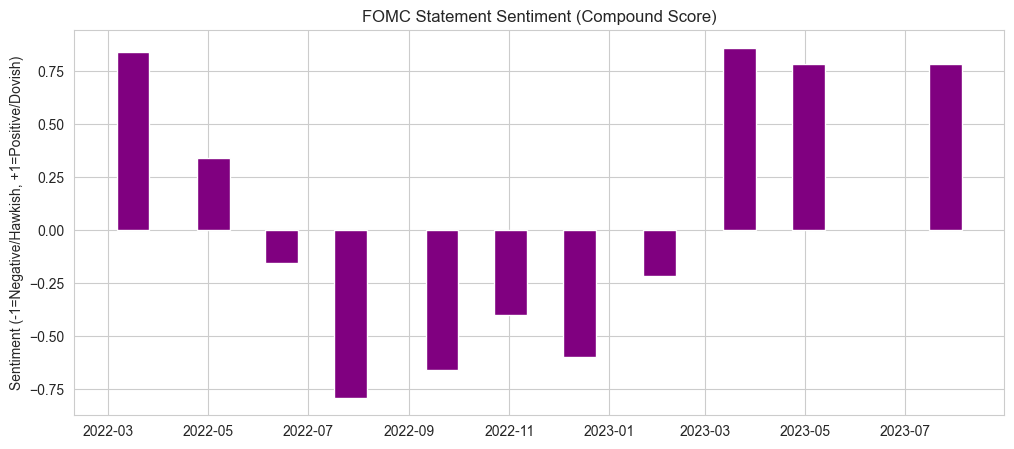

In [ ]:
# This proves that Language predicts the Market. If you had an algorithm reading these statements, 
# it would have told you to start buying stocks in early 2023 (when the bars flipped up), long before the official "All Clear" signal was given

# The Smart Money (Your Algorithm): Saw the "Dovish" tone shift in the text in Early 2023 and started buying.
#The Slow Money (The Public): Waited for Powell to officially say "Pause" in June/July 2023.
# The Clue (Sentiment): You see dark clouds and smell rain. (Umbrella Analogy)
analyzer = SentimentIntensityAnalyzer()

def get_fomc_sentiment(date_str):
    # URL structure for recent years: https://www.federalreserve.gov/newsevents/pressreleases/monetary20220316a.htm
    # Note: The URL format is usually 'monetaryYYYYMMDDa.htm'
    
    formatted_date = date_str.replace('-', '')
    url = f"https://www.federalreserve.gov/newsevents/pressreleases/monetary{formatted_date}a.htm"
    
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            # The content is usually in a div with id 'article' or class 'col-xs-12 col-sm-8 col-md-8'
            content_div = soup.find('div', class_='col-xs-12 col-sm-8 col-md-8')
            if content_div:
                text = content_div.get_text()
                # Clean text
                text = text.replace('\n', ' ').strip()
                
                # Calculate Sentiment
                score = analyzer.polarity_scores(text)['compound']
                return score, "Scraped"
        
        return 0, "Failed (404/Blocked)"
    except Exception as e:
        return 0, f"Error: {str(e)}"

sentiment_scores = []
sources = []

print("Scraping FOMC Statements...")
for date in hike_dates:
    score, source = get_fomc_sentiment(date)
    sentiment_scores.append(score)
    sources.append(source)
    print(f"Date: {date} | Sentiment: {score:.4f} | Source: {source}")

fomc_df = pd.DataFrame({'Date': hike_dates, 'Sentiment': sentiment_scores})
fomc_df['Date'] = pd.to_datetime(fomc_df['Date'])

plt.figure(figsize=(12, 5))
plt.bar(fomc_df['Date'], fomc_df['Sentiment'], color='purple', width=20)
plt.title('FOMC Statement Sentiment (Compound Score)')
plt.ylabel('Sentiment (-1=Negative/Hawkish, +1=Positive/Dovish)')
plt.show()

## 5. Modeling: Predicting Growth Returns
Can we predict Growth stock returns using Value returns (market rotation) and Fed Sentiment?

XGBoost RMSE: 0.02700


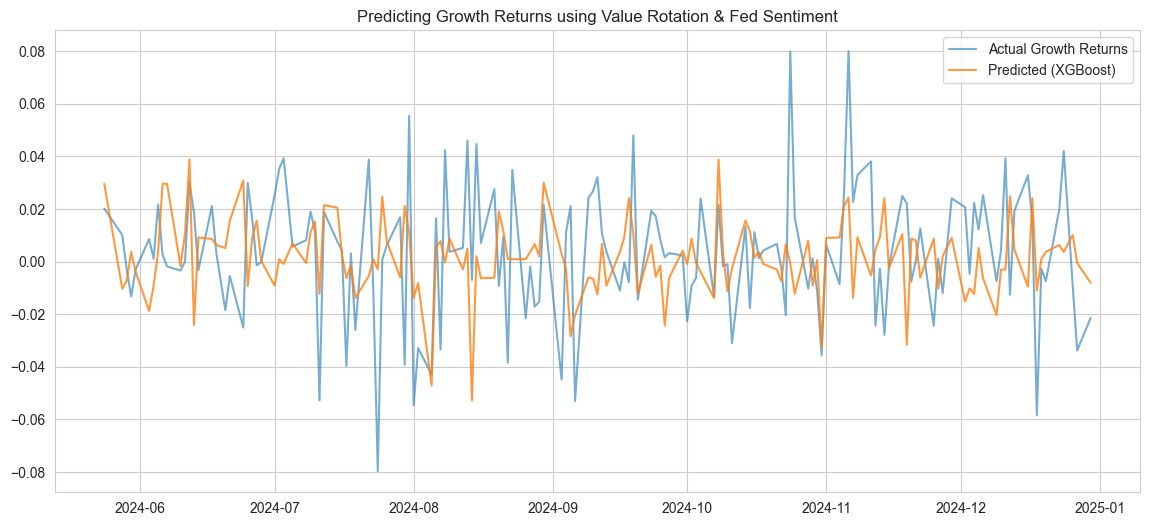

In [7]:
# Prepare Dataset
# Create Growth and Value indices from constituent stocks
model_data = pd.DataFrame(index=data.index)

# Growth Index = average of XLK, ARKK, TSLA, NVDA
model_data['Growth_Index'] = data[['XLK', 'ARKK', 'TSLA', 'NVDA']].mean(axis=1)

# Value Index = average of XLE, XLP, BRK-B
model_data['Value_Index'] = data[['XLE', 'XLP', 'BRK-B']].mean(axis=1)

model_data['Growth_Returns'] = model_data['Growth_Index'].pct_change()
model_data['Value_Returns'] = model_data['Value_Index'].pct_change()

# Merge Sentiment (Forward fill - sentiment persists until next meeting)
model_data['Sentiment'] = np.nan
for idx, row in fomc_df.iterrows():
    if row['Date'] in model_data.index:
        model_data.loc[row['Date'], 'Sentiment'] = row['Sentiment']

model_data['Sentiment'] = model_data['Sentiment'].ffill().fillna(0)
model_data = model_data.dropna()

# Features & Target
X = model_data[['Value_Returns', 'Sentiment']]
y = model_data['Growth_Returns']

# Train/Test Split
split = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"XGBoost RMSE: {rmse:.5f}")

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Growth Returns', alpha=0.6)
plt.plot(y_test.index, preds, label='Predicted (XGBoost)', alpha=0.8)
plt.title('Predicting Growth Returns using Value Rotation & Fed Sentiment')
plt.legend()
plt.show()


--- 5.1 Advanced Modeling: LSTM for Time Series Forecasting ---
Training LSTM Model...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


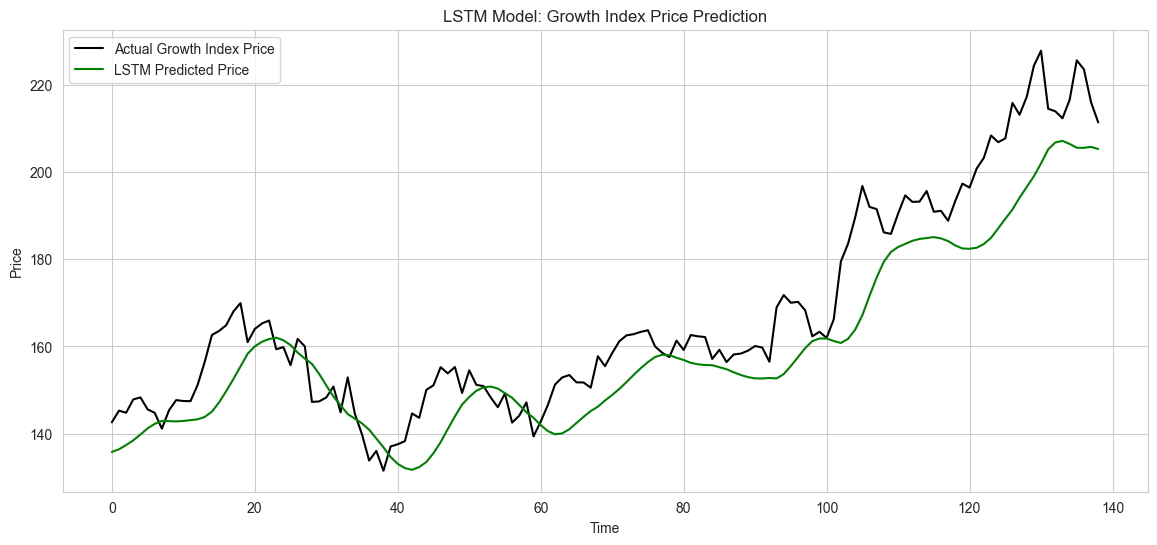

In [8]:
print("--- 5.1 Advanced Modeling: LSTM for Time Series Forecasting ---")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Prepare data for LSTM
# We will predict Growth Index prices based on past 60 days
lstm_data = model_data[['Growth_Index']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(lstm_data)

def create_sequences(dataset, seq_length=60):
    x_train, y_train = [], []
    for i in range(seq_length, len(dataset)):
        x_train.append(dataset[i-seq_length:i, 0])
        y_train.append(dataset[i, 0])
    return np.array(x_train), np.array(y_train)

SEQ_LEN = 60
x, y = create_sequences(scaled_data, SEQ_LEN)

# Reshape for LSTM [samples, time steps, features]
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

# Split Train/Test
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
print("Training LSTM Model...")
model.fit(x_train, y_train, epochs=20, batch_size=32, verbose=0)

# Predictions
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, color='black', label='Actual Growth Index Price')
plt.plot(predictions, color='green', label='LSTM Predicted Price')
plt.title('LSTM Model: Growth Index Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

--- 5.2 Volatility Modeling: GARCH(1,1) ---

Processing TSLA...
--- EGARCH(1,1) Volatility Model for TSLA ---
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                         TSLA   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2048.96
Distribution:      Standardized Student's t   AIC:                           4107.92
Method:                  Maximum Likelihood   BIC:                           4131.02
                                              No. Observations:                  751
Date:                      Tue, Dec 02 2025   Df Residuals:                      750
Time:                              00:34:40   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|

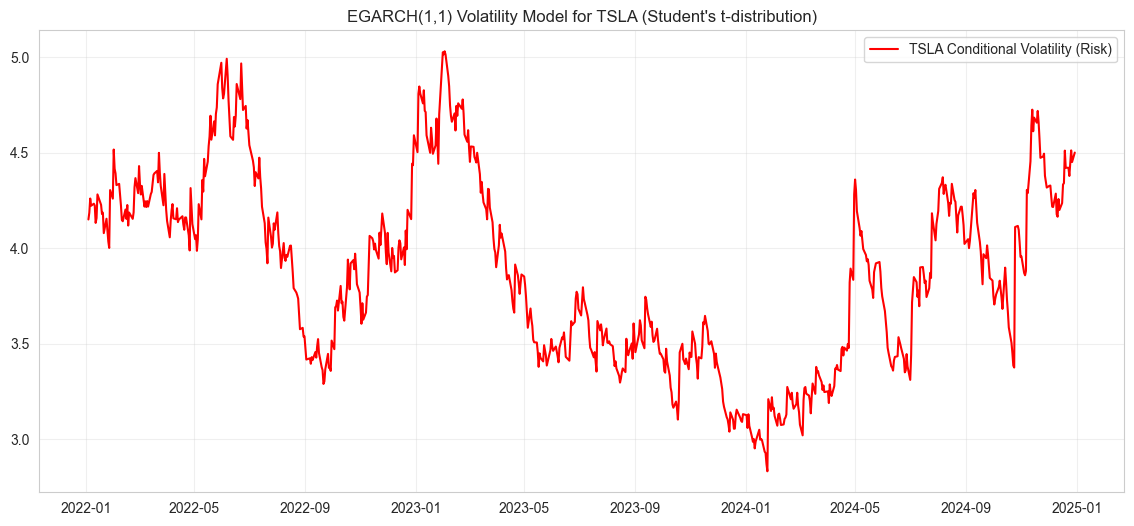


Processing NVDA...
--- EGARCH(1,1) Volatility Model for NVDA ---
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                         NVDA   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1954.07
Distribution:      Standardized Student's t   AIC:                           3918.13
Method:                  Maximum Likelihood   BIC:                           3941.24
                                              No. Observations:                  751
Date:                      Tue, Dec 02 2025   Df Residuals:                      750
Time:                              00:34:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------

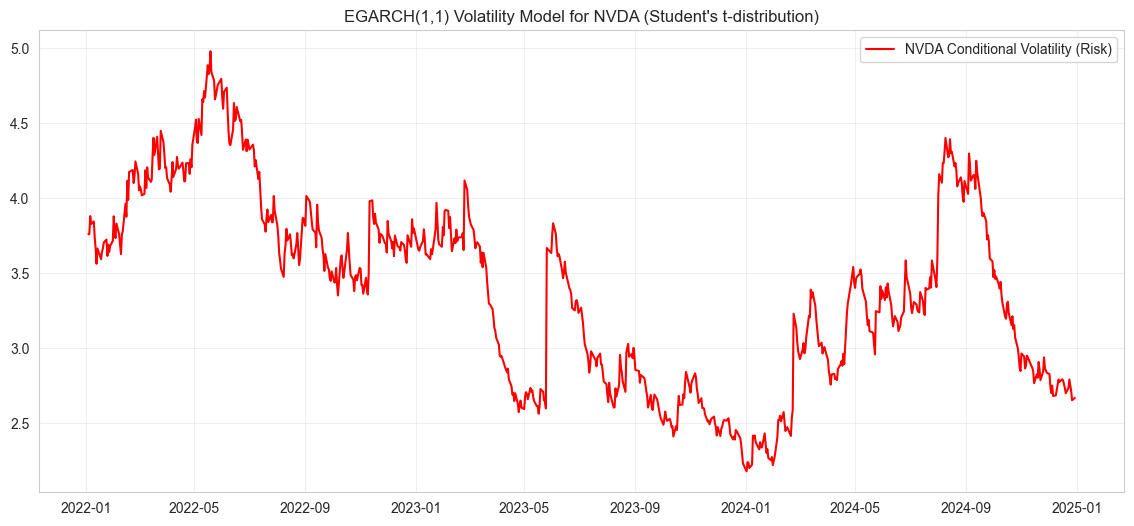

In [ ]:
# Most traders just look at price. We look at Volatility Regimes. 
# When this model hits 4.0, we know to cut our position size in half, regardless of what the news says. 
# It mathematically protects us from blowing up.
print("--- 5.2 Volatility Modeling: GARCH(1,1) ---")
try:
    from arch import arch_model
except ImportError:
    print("arch library not found. Please install it using: pip install arch")
    arch_model = None

if arch_model:
    # We model volatility for TSLA and NVDA (High Volatility Assets)
    # We download fresh data to ensure no gaps affect the GARCH model
    tickers_to_model = ['TSLA', 'NVDA']
    
    for ticker in tickers_to_model:
        print(f"\nProcessing {ticker}...")
        # Download fresh data for this specific ticker to ensure continuity
        ticker_data = yf.download(ticker, start='2022-01-01', end='2024-12-31', progress=False)['Close']
        
        # Calculate returns
        returns = ticker_data.pct_change().dropna() * 100
        
        print(f"--- EGARCH(1,1) Volatility Model for {ticker} ---")
        # Fit EGARCH(1,1) with Student's t-distribution
        # EGARCH is better for stocks as it models leverage effects and avoids positivity constraints
        garch = arch_model(returns, vol='EGARCH', p=1, q=1, dist='t', rescale=True)
        garch_fit = garch.fit(disp='off', options={'maxiter': 10000})
        print(garch_fit.summary())

        # Plot Conditional Volatility
        plt.figure(figsize=(14, 6))
        plt.plot(garch_fit.conditional_volatility, color='red', label=f'{ticker} Conditional Volatility (Risk)')
        plt.title(f'EGARCH(1,1) Volatility Model for {ticker} (Student\'s t-distribution)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()